In [190]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap
from matplotlib.pyplot import title
from openpyxl.styles.numbers import COLORS

from source.fuse_dual_tomograms import segment_backround_otsu

# =============================================================
# ANATOMICAL MEASUREMENTS FROM EXCEL
# =============================================================
# Path hardcoded al file Excel
EXCEL_PATH = '/home/fra/Pycharm_Projects/whole_heart/data/Anatomical_Measurements_mid_cavity_dataframe.xlsx'
# Load the Excel file as a dataframa, where the first row is the header, first column is group, second column is the index, and the rest are the values
anatomical_measurements = pd.read_excel(EXCEL_PATH, header=0, index_col=0)
anatomical_measurements

,Group,60,0,300,240,180,120
Sample,,,,,,,
N1,PATHOL,1667.387,1389.184,1724.027,1353.160,1592.897,1738.392
N2,PATHOL,1320.659,1336.298,1561.969,598.383,724.772,1006.039
N3,PATHOL,1298.877,1471.244,1569.910,1298.877,1319.792,1417.443
N4,PATHOL,1861.421,1299.281,824.586,1541.746,1537.482,1192.581
N6,PATHOL,2003.182,1621.966,1526.120,1577.838,1598.963,1391.029
N7,PATHOL,1507.609,1536.592,1841.789,1664.089,725.133,1803.272
N8,PATHOL,1872.403,1577.407,1696.354,1690.771,362.804,990.129
N9,PATHOL,1497.962,1462.572,1806.325,1544.594,1044.695,702.358
N10,PATHOL,2101.907,1473.568,1600.965,1039.107,736.784,1333.781


In [191]:
# Ordina le colonne del dataframe (dalla seconda in poi) in ordine crescente basandosi sui valori dell'header
# anatomical_measurements = anatomical_measurements.iloc[:, :1].join(anatomical_measurements.iloc[:, 1:].reindex(sorted(anatomical_measurements.columns[1:]), axis=1))
# anatomical_measurements

anatomical_measurements.columns = ['Group', '0', '60', '120', '180', '240', '300']
anatomical_measurements

,Group,0,60,120,180,240,300
Sample,,,,,,,
N1,PATHOL,1667.387,1389.184,1724.027,1353.160,1592.897,1738.392
N2,PATHOL,1320.659,1336.298,1561.969,598.383,724.772,1006.039
N3,PATHOL,1298.877,1471.244,1569.910,1298.877,1319.792,1417.443
N4,PATHOL,1861.421,1299.281,824.586,1541.746,1537.482,1192.581
N6,PATHOL,2003.182,1621.966,1526.120,1577.838,1598.963,1391.029
N7,PATHOL,1507.609,1536.592,1841.789,1664.089,725.133,1803.272
N8,PATHOL,1872.403,1577.407,1696.354,1690.771,362.804,990.129
N9,PATHOL,1497.962,1462.572,1806.325,1544.594,1044.695,702.358
N10,PATHOL,2101.907,1473.568,1600.965,1039.107,736.784,1333.781


In [192]:
## Riordina le colonne del DataFrame
anatomical_measurements = anatomical_measurements[['Group', '300', '0', '60', '120', '180', '240']]

# sovrascrivi il nome delle colonne
anatomical_measurements.columns = ['Group', '0', '60', '120', '180', '240', '300']
anatomical_measurements

,Group,0,60,120,180,240,300
Sample,,,,,,,
N1,PATHOL,1738.392,1667.387,1389.184,1724.027,1353.160,1592.897
N2,PATHOL,1006.039,1320.659,1336.298,1561.969,598.383,724.772
N3,PATHOL,1417.443,1298.877,1471.244,1569.910,1298.877,1319.792
N4,PATHOL,1192.581,1861.421,1299.281,824.586,1541.746,1537.482
N6,PATHOL,1391.029,2003.182,1621.966,1526.120,1577.838,1598.963
N7,PATHOL,1803.272,1507.609,1536.592,1841.789,1664.089,725.133
N8,PATHOL,990.129,1872.403,1577.407,1696.354,1690.771,362.804
N9,PATHOL,702.358,1497.962,1462.572,1806.325,1544.594,1044.695
N10,PATHOL,1333.781,2101.907,1473.568,1600.965,1039.107,736.784


In [193]:
# genera le medie divise per Group
wall_thickness_avg = anatomical_measurements.groupby('Group').mean()
wall_thickness_avg

,0,60,120,180,240,300
Group,,,,,,
CTRL,1471.514889,1391.490444,1577.270667,1652.636556,1454.366556,1454.143667
PATHOL,1286.113778,1681.267444,1463.123556,1572.449444,1367.618333,1071.480222


In [194]:
# crea un plot radiale della wall thickness
def plot_radial_wall_thickness(wall_thickness_avg, group='CTRL'):
    """
    Plotta la wall thickness media per un gruppo specifico in un grafico radiale.

    Args:
        wall_thickness_avg (pd.DataFrame): DataFrame con le misure di wall thickness medie.
        group (str): Il gruppo da plottare ('CTRL' o 'PATHOL').
    """
    # Estrai i valori della wall thickness per il gruppo specificato
    values = wall_thickness_avg.loc[group].values
    print("values:", values)

    # Crea un array di angoli per il grafico radiale
    angles = np.linspace(0, 2 * np.pi, len(values), endpoint=False).tolist()
    print("angles:", angles)

    # Completa il cerchio
    values = np.concatenate((values, [values[0]]))
    angles += angles[:1]

    # Crea il grafico radiale
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    ax.fill(angles, values, color='blue', alpha=0.25)
    ax.plot(angles, values, color='blue', linewidth=2)

    # Imposta le etichette degli angoli
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(wall_thickness_avg.columns.tolist(), fontsize=10)

    # Imposta il titolo
    ax.set_title(f'Wall Thickness Media - {group}', fontsize=16)

    plt.show()

values: [1471.51488889 1391.49044444 1577.27066667 1652.63655556 1454.36655556
 1454.14366667]
angles: [0.0, 1.0471975511965976, 2.0943951023931953, 3.141592653589793, 4.1887902047863905, 5.235987755982988]


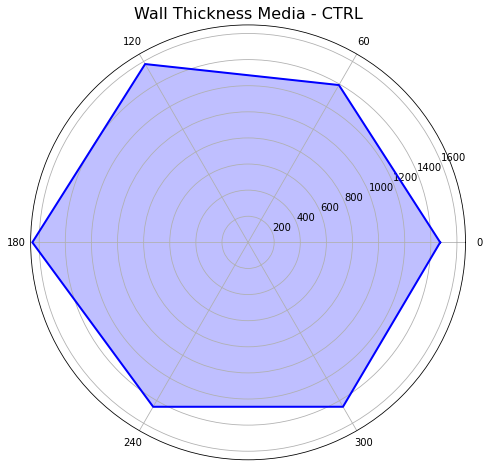

In [195]:
plot_radial_wall_thickness(wall_thickness_avg, group='CTRL')

values: [1286.11377778 1681.26744444 1463.12355556 1572.44944444 1367.61833333
 1071.48022222]
angles: [0.0, 1.0471975511965976, 2.0943951023931953, 3.141592653589793, 4.1887902047863905, 5.235987755982988]


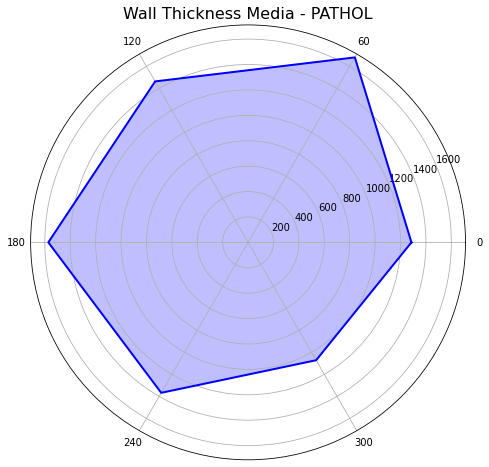

In [196]:
plot_radial_wall_thickness(wall_thickness_avg, group='PATHOL')

## ==========================
# COLLAGEN DATA
## ==========================

In [198]:
import os
# =============================================================
# LOAD DATAFRAMES OF AMOUNT OF COLLAGEN FROM PICKLE FILES
# =============================================================
base_path = '/home/fra/Pycharm_Projects/whole_heart/data/data_from_luca/average_dict_radii_theta'

# load dataframes from these paths:
# ----------------- MM3
# CTRL_CF_path = os.path.join(base_path, 'CTRL_CF_avg_dict_mm3.pkl')
# CTRL_NCF_path = os.path.join(base_path, 'CTRL_NCF_avg_dict_mm3.pkl')
# PATHOL_CF_path = os.path.join(base_path, 'PATHOL_CF_avg_dict_mm3.pkl')
# PATHOL_NCF_path = os.path.join(base_path, 'PATHOL_NCF_avg_dict_mm3.pkl')

# ------------------- PERCENTAGE
CTRL_CF_path = os.path.join(base_path, 'CTRL_perc_CF.pkl')
CTRL_NCF_path = os.path.join(base_path, 'CTRL_perc_NCF.pkl')
PATHOL_CF_path = os.path.join(base_path, 'PATHOL_perc_CF.pkl')
PATHOL_NCF_path = os.path.join(base_path, 'PATHOL_perc_NCF.pkl')


# load the dataframes using pickle
CTRL_CF = pd.read_pickle(CTRL_CF_path)
CTRL_NCF = pd.read_pickle(CTRL_NCF_path)
PATHOL_CF = pd.read_pickle(PATHOL_CF_path)
PATHOL_NCF = pd.read_pickle(PATHOL_NCF_path)

print("CTRL_CF shape:", CTRL_CF.shape)
print("CTRL_NCF shape:", CTRL_NCF.shape)
print("PATHOL_CF shape:", PATHOL_CF.shape)
print("PATHOL_NCF shape:", PATHOL_NCF.shape)

 

CTRL_CF shape: (16, 16)
CTRL_NCF shape: (16, 16)
PATHOL_CF shape: (16, 16)
PATHOL_NCF shape: (16, 16)


In [199]:
CTRL_CF

,0,22,45,67,90,112,135,157,180,202,225,247,270,292,315,337
15.738889,0.070876,0.164143,0.083086,0.027117,0.199457,0.084349,0.356712,0.298666,0.139882,0.071052,0.066485,0.027477,0.070996,0.155983,0.131336,0.060230
31.477778,0.042258,0.022942,0.160990,0.365609,0.222336,0.097216,0.070874,0.108992,0.205271,0.227116,0.226642,0.058462,0.145574,0.194913,0.237051,0.172257
47.216667,0.099564,0.117967,0.129612,0.137467,0.049417,0.106270,0.090552,0.100517,0.178192,0.172991,0.189640,0.112381,0.945678,0.212180,0.316596,0.137760
62.955556,0.100467,0.082718,0.147170,0.103123,0.144138,0.106409,0.047740,0.082768,0.100773,0.940249,0.623451,0.186921,1.415596,0.291261,0.391256,0.147284
78.694444,0.052098,0.182597,0.237989,0.215996,0.357597,0.083540,0.072109,0.151470,0.261631,0.294845,0.371923,0.238279,0.270328,0.405503,0.575962,0.415001
94.433333,0.146045,0.112988,0.315649,0.201969,0.699925,0.253449,0.066322,0.171116,0.582618,0.654219,0.766131,0.437334,0.274869,0.165383,0.275239,0.213067
110.172222,0.174755,0.062141,0.152645,1.159764,0.410136,0.314987,0.263790,0.316899,0.345668,0.402281,0.324750,0.448019,0.176690,0.237779,0.261807,0.152983
125.911111,0.183424,0.087297,0.171884,0.204471,0.412580,0.236575,0.637040,0.368693,0.493188,0.560225,0.523679,0.304162,0.349335,0.184581,0.280225,0.222894
141.650000,0.133962,0.164321,0.401629,0.432804,0.601844,0.230824,0.509081,0.658228,0.401501,0.668642,0.583739,0.444286,0.176038,0.178478,0.250618,0.217110
157.388889,0.187473,0.690030,0.823441,0.596526,0.894376,0.337527,0.698382,1.363883,0.500793,0.534513,0.362492,0.262189,0.186504,0.193225,0.197095,0.234581


In [200]:
CTRL_NCF

,0,22,45,67,90,112,135,157,180,202,225,247,270,292,315,337
15.738889,0.982139,0.788320,0.806109,1.487245,2.442579,2.210337,2.014764,2.476170,1.987342,1.159752,0.545986,0.750124,0.457036,0.368959,0.834225,0.996808
31.477778,0.426045,0.361636,0.949786,2.221295,1.908107,1.631004,1.211384,1.680422,1.704889,0.902486,0.705338,0.667924,1.114146,1.510579,1.077190,1.156330
47.216667,0.608968,0.470683,1.732616,2.324315,1.018975,0.885585,0.564531,1.022572,1.746471,0.924170,0.853058,0.788276,1.750256,1.226124,1.612087,1.276928
62.955556,0.738505,0.732888,2.278140,1.876274,1.441632,0.608265,0.394595,0.574713,0.903466,2.498962,2.439857,1.106328,1.873459,1.145441,1.395267,1.564776
78.694444,0.544010,1.384367,2.190670,1.973033,1.283494,0.471101,0.373985,1.133991,1.657459,2.198393,1.543047,1.100878,0.958022,1.329256,2.081104,1.493619
94.433333,0.640161,1.124070,1.808587,1.367788,1.637612,0.684764,0.357741,1.014157,2.468629,2.273339,1.938179,1.257961,1.310450,1.160352,1.909796,1.719117
110.172222,0.781265,1.065547,2.018936,1.750867,1.427609,0.838338,0.906235,1.426153,2.218757,2.585619,2.059187,1.444195,1.285663,1.517668,2.194437,1.339438
125.911111,0.785487,1.123513,2.119667,1.369162,1.305688,0.799339,1.529488,1.969727,3.601066,2.963739,2.330159,1.343442,1.313378,1.312560,1.559180,0.918044
141.650000,0.610543,1.232483,2.183427,2.471374,1.969946,0.853238,2.405282,5.081370,4.687203,3.786494,2.832690,1.837617,0.989793,1.262680,1.471596,1.090488
157.388889,1.088554,1.970957,3.492654,4.111749,2.798388,1.903720,4.696562,9.487498,6.161914,4.926854,1.844283,1.458730,0.800898,0.936527,1.983824,1.353067


In [201]:
# somma CTRL_perc_CF and CTRL_perc_NCF
CTRL_tot_fibrosis = CTRL_CF + CTRL_NCF
# somma PATHOL_perc_CF and PATHOL_perc_NCF
PATHOL_tot_fibrosis = PATHOL_CF + PATHOL_NCF

CTRL_tot_fibrosis

print('Check value (1,1):')
print('1000* CTRL_CF.iloc[1, 1]:', 1000* CTRL_CF.iloc[1, 1])  # Stampa il valore della cella (1, 1)
print('1000* CTRL_NCF.iloc[1, 1]:', 1000* CTRL_NCF.iloc[1, 1])  # Stampa il valore della cella (1, 1)
print('1000* CTRL_tot_fibrosis.iloc[1, 1]:', 1000* CTRL_tot_fibrosis.iloc[1, 1])  # Stampa il valore della cella (1, 1)


Check value (1,1):
1000* CTRL_CF.iloc[1, 1]: 22.941872539786036
1000* CTRL_NCF.iloc[1, 1]: 361.6363592455746
1000* CTRL_tot_fibrosis.iloc[1, 1]: 384.5782317853607


In [202]:
# save as excel files
CTRL_tot_fibrosis.to_excel('/home/fra/Pycharm_Projects/whole_heart/data/CTRL_total_fibrosis_perc.xlsx')
PATHOL_tot_fibrosis.to_excel('/home/fra/Pycharm_Projects/whole_heart/data/PATHOL_total_fibrosis_perc.xlsx')

In [203]:
# SOMMA PER TUTTI I RAGGI
# somma le colonne di CTRL_perc_fibrosis
CTRL_fibrosis_theta = CTRL_tot_fibrosis.sum(axis=0)
# somma le colonne di PATHOL_perc_fibrosis
PATHOL_fibrosis_theta = PATHOL_tot_fibrosis.sum(axis=0)

print(CTRL_fibrosis_theta.index.tolist())
print(CTRL_fibrosis_theta.values)
print(PATHOL_fibrosis_theta.index.tolist())
print(PATHOL_fibrosis_theta.values)

[0, 22, 45, 67, 90, 112, 135, 157, 180, 202, 225, 247, 270, 292, 315, 337]
[17.61777489 29.99951703 27.96847669 27.86737055 25.54990455 17.57717311
 29.75146776 41.16460399 42.93637558 44.03013992 27.87247876 22.15679801
 24.00539031 18.16656655 24.06393442 24.57619875]
[0, 22, 45, 67, 90, 112, 135, 157, 180, 202, 225, 247, 270, 292, 315, 337]
[ 66.7882738   85.10388649  71.1888604   37.78965854  60.56107772
  74.96936832  69.51996411  34.14652423  23.3577163   67.62729123
  59.70708205  80.11364845 247.00655885 191.47917506  84.58985058
  51.0499254 ]


In [204]:

# save as excel files
CTRL_fibrosis_theta.to_excel('/home/fra/Pycharm_Projects/whole_heart/data/CTRL_total_fibrosis_SUM_on_radii.xlsx')
PATHOL_fibrosis_theta.to_excel('/home/fra/Pycharm_Projects/whole_heart/data/PATHOL_total_fibrosis_SUM_on_radii.xlsx')
# =============================================================

# Print the results

print("\n\n *** wall_thickness:", wall_thickness_avg)
print("\n\n *** CTRL_perc_fibrosis_sum:", CTRL_fibrosis_theta)
print("\n\n *** PATHOL_perc_fibrosis_sum:", PATHOL_fibrosis_theta)


#===========================================================
# stampa i nomi delle colonne di CTRL_perc_fibrosis_sum
print("\n\n *** CTRL_perc_fibrosis_sum columns:", CTRL_fibrosis_theta.index.tolist())







 *** wall_thickness:                   0           60          120          180          240  \
Group                                                                     
CTRL    1471.514889  1391.490444  1577.270667  1652.636556  1454.366556   
PATHOL  1286.113778  1681.267444  1463.123556  1572.449444  1367.618333   

                300  
Group                
CTRL    1454.143667  
PATHOL  1071.480222  


 *** CTRL_perc_fibrosis_sum: 0      17.617775
22     29.999517
45     27.968477
67     27.867371
90     25.549905
112    17.577173
135    29.751468
157    41.164604
180    42.936376
202    44.030140
225    27.872479
247    22.156798
270    24.005390
292    18.166567
315    24.063934
337    24.576199
dtype: float64


 *** PATHOL_perc_fibrosis_sum: 0       66.788274
22      85.103886
45      71.188860
67      37.789659
90      60.561078
112     74.969368
135     69.519964
157     34.146524
180     23.357716
202     67.627291
225     59.707082
247     80.113648
270    247.006559
292

In [205]:
# usa plot_radial_wall_thickness per CTRL e PATHOL

In [206]:
import matplotlib.pyplot as plt
import numpy as np

def plot_radial_fibrosis(data, title="Radial Plot", color='green'):
    """
    Plotta i dati di CTRL_CF in un grafico radiale.

    Args:
        ctrl_cf_data (pd.DataFrame): DataFrame con i dati di CTRL_CF.
        title (str): Titolo del grafico.
    """
    # Estrai i valori e gli angoli
    values = data.values
    angles = np.linspace(0, 2 * np.pi, len(values), endpoint=False).tolist()

    # Completa il cerchio
    values = np.concatenate((values, [values[0]]))
    angles += angles[:1]

    # Crea il grafico radiale
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.plot(angles, values, color=color, linewidth=2)

    # Imposta le etichette degli angoli
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(data.index.tolist(), fontsize=10)

    # Imposta il titolo
    ax.set_title(title, fontsize=16)

    plt.show()



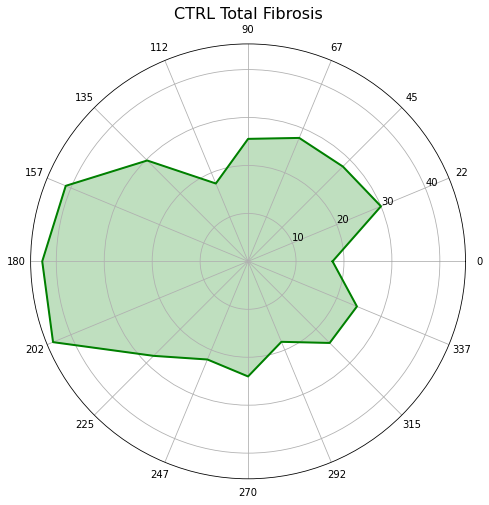

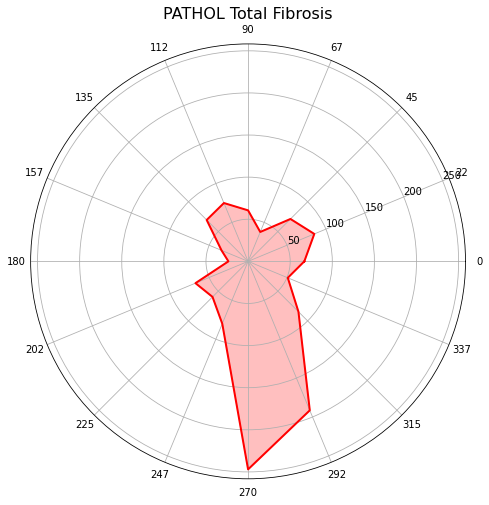

In [207]:
plot_radial_fibrosis(CTRL_fibrosis_theta, title="CTRL Total Fibrosis", color='green')
plot_radial_fibrosis(PATHOL_fibrosis_theta, title="PATHOL Total Fibrosis", color='red')

In [208]:
# Estrai gli header di wall_thickness_avg (angoli in gradi)
original_angles = np.array(wall_thickness_avg.columns, dtype=float)

# Estrai gli header di CTRL_perc_fibrosis_sum (angoli in gradi)
target_angles = np.array(CTRL_fibrosis_theta.index, dtype=float)

# Interpola i valori per ciascuna riga di wall_thickness_avg
wall_thickness_avg_interp = wall_thickness_avg.apply(
    lambda row: np.interp(target_angles, original_angles, row.values), axis=1
)

# Converti il risultato in un DataFrame con gli stessi header di CTRL_perc_fibrosis_sum
wall_thickness_avg_interp = pd.DataFrame(
    wall_thickness_avg_interp.tolist(),
    index=wall_thickness_avg.index,
    columns=CTRL_fibrosis_theta.index
)

# Stampa il risultato
wall_thickness_avg_interp

,0,22,45,67,90,112,135,157,180,202,225,247,270,292,315,337
Group,,,,,,,,,,,,,,,,
CTRL,1471.514889,1442.172593,1411.496556,1413.164804,1484.380556,1552.499970,1596.112139,1623.746298,1652.636556,1579.937556,1503.934056,1454.340552,1454.255111,1454.173385,1454.143667,1454.143667
PATHOL,1286.113778,1431.003456,1582.479028,1655.817324,1572.195500,1492.209407,1490.455028,1530.541187,1572.449444,1497.344704,1418.826111,1333.068887,1219.549278,1110.965304,1071.480222,1071.480222


In [251]:
# sposto di una colonna a sinistra
columns= wall_thickness_avg_interp.columns.tolist()
new_columns = columns[1:] + [columns[0]]

wall_thickness_avg_interp[columns] = wall_thickness_avg_interp[new_columns]
wall_thickness_avg_interp

,0,22,45,67,90,112,135,157,180,202,225,247,270,292,315,337
Group,,,,,,,,,,,,,,,,
CTRL,1442.172593,1411.496556,1413.164804,1484.380556,1552.499970,1596.112139,1623.746298,1652.636556,1579.937556,1503.934056,1454.340552,1454.255111,1454.173385,1454.143667,1454.143667,1471.514889
PATHOL,1431.003456,1582.479028,1655.817324,1572.195500,1492.209407,1490.455028,1530.541187,1572.449444,1497.344704,1418.826111,1333.068887,1219.549278,1110.965304,1071.480222,1071.480222,1286.113778


In [252]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

def plot_radial_wall_thickness_colored(wall_thickness_avg, group='CTRL', title='Radial Plot', filepath='output'):
    """
    Plotta la wall thickness media per un gruppo specifico in un grafico radiale, con valori in mm,
    colorando ogni segmento del bordo in base al proprio valore.
    """
    # Estrai i valori e converti in mm
    values = wall_thickness_avg.loc[group].values / 1000
    labels = wall_thickness_avg.columns.tolist()
    
    # Costruisci gli angoli
    angles = np.linspace(0, 2 * np.pi, len(values), endpoint=False)
    
    # Chiudi il cerchio
    angles = np.concatenate((angles, [angles[0]]))
    values = np.concatenate((values, [values[0]]))

    # Costruisci segmenti per colorare la linea
    points = np.array([angles, values]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # Mappa colori
    norm = Normalize(vmin=min(values), vmax=max(values))
    cmap = plt.cm.plasma_r
    lc = LineCollection(segments, cmap=cmap, norm=norm)
    lc.set_array(values[:-1])
    lc.set_linewidth(4)

    # Setup plot
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 8))
    ax.add_collection(lc)

    # Plot anche i punti (facoltativo)
    ax.plot(angles, values, color='black', alpha=0.3, linewidth=0.5)

    # Etichette
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_yticklabels([])
    ax.set_title(title, fontsize=16)

    # Colorbar
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array(values)
    cbar = plt.colorbar(sm, ax=ax, pad=0.1)
    cbar.set_label('Wall Thickness (mm)', fontsize=12)

    # Salva
    plt.savefig(f"{filepath}.png", dpi=300, bbox_inches='tight')
    plt.savefig(f"{filepath}.pdf", bbox_inches='tight')
    plt.show()

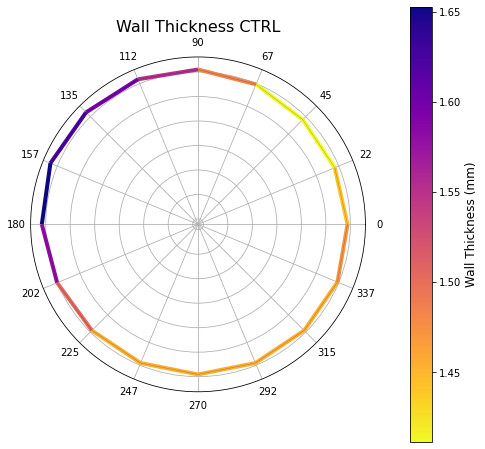

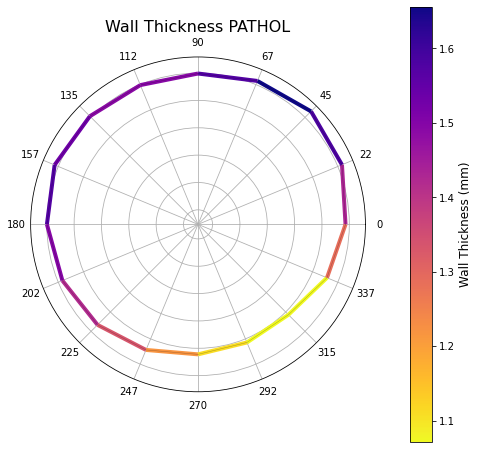

In [253]:
plot_radial_wall_thickness_colored(wall_thickness_avg_interp, group='CTRL', title='Wall Thickness CTRL', filepath='/home/fra/Pycharm_Projects/whole_heart/data/wall_thickness_CTRL')
plot_radial_wall_thickness_colored(wall_thickness_avg_interp, group='PATHOL', title='Wall Thickness PATHOL', filepath='/home/fra/Pycharm_Projects/whole_heart/data/wall_thickness_PATHOL')

In [254]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

def plot_radial_wall_thickness_colored(wall_thickness_avg, group='CTRL', title='Radial Plot', filepath='output'):
    """
    Plotta la wall thickness media per un gruppo specifico in un grafico radiale,
    colorando ogni segmento in base al proprio valore tra 1 e 2 mm.
    Valori inferiori a 1 mm verranno mostrati come gialli.
    """
    # Estrai i valori e converti in mm
    values = wall_thickness_avg.loc[group].values / 1000
    labels = wall_thickness_avg.columns.tolist()
    
    # Angoli
    angles = np.linspace(0, 2 * np.pi, len(values), endpoint=False)
    angles = np.concatenate((angles, [angles[0]]))
    values = np.concatenate((values, [values[0]]))

    # Segmenti
    points = np.array([angles, values]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # Colormap da 1.0 a 2.0 mm
    norm = Normalize(vmin=1.0, vmax=2.0)
    cmap = plt.cm.plasma_r
    lc = LineCollection(segments, cmap=cmap, norm=norm)
    lc.set_array(values[:-1])
    lc.set_linewidth(4)

    # Setup plot
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 8))
    ax.add_collection(lc)

    # Asse radiale da 0 a 2 mm
    ax.set_ylim(0, 2.0)

    # Linea guida sottile
    ax.plot(angles, values, color='black', alpha=0.3, linewidth=0.5)

    # Etichette
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_yticklabels([])
    ax.set_title(title, fontsize=16)

    # Colorbar da 1 a 2 mm
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array(values)
    cbar = plt.colorbar(sm, ax=ax, pad=0.1)
    cbar.set_label('Wall Thickness (mm)', fontsize=12)
    cbar.set_ticks([1.0, 1.5, 2.0])
    
    # Salvataggio
    plt.savefig(f"{filepath}.png", dpi=300, bbox_inches='tight')
    plt.savefig(f"{filepath}.pdf", bbox_inches='tight')
    plt.show()

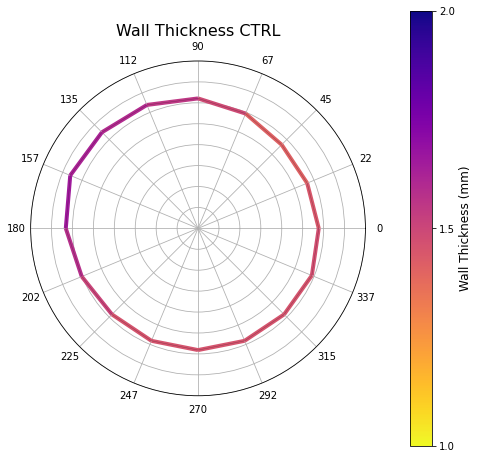

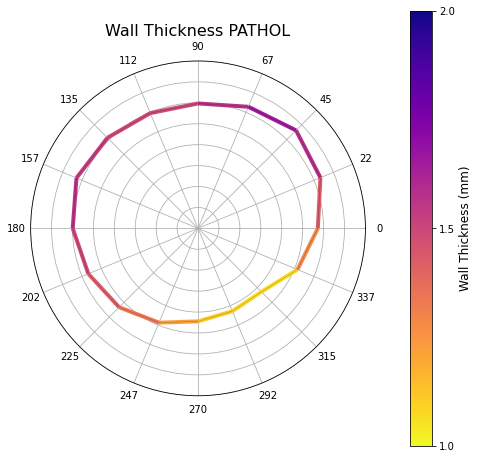

In [255]:
plot_radial_wall_thickness_colored(wall_thickness_avg_interp, group='CTRL', title='Wall Thickness CTRL', filepath='/home/fra/Pycharm_Projects/whole_heart/data/wall_thickness_CTRL')
plot_radial_wall_thickness_colored(wall_thickness_avg_interp, group='PATHOL', title='Wall Thickness PATHOL', filepath='/home/fra/Pycharm_Projects/whole_heart/data/wall_thickness_PATHOL')

values: [1442.17259259 1411.49655556 1413.1648037  1484.38055556 1552.49997037
 1596.11213889 1623.74629815 1652.63655556 1579.93755556 1503.93405556
 1454.34055185 1454.25511111 1454.17338519 1454.14366667 1454.14366667
 1471.51488889]
angles: [0.0, 0.39269908169872414, 0.7853981633974483, 1.1780972450961724, 1.5707963267948966, 1.9634954084936207, 2.356194490192345, 2.748893571891069, 3.141592653589793, 3.5342917352885173, 3.9269908169872414, 4.319689898685965, 4.71238898038469, 5.105088062083414, 5.497787143782138, 5.890486225480862]


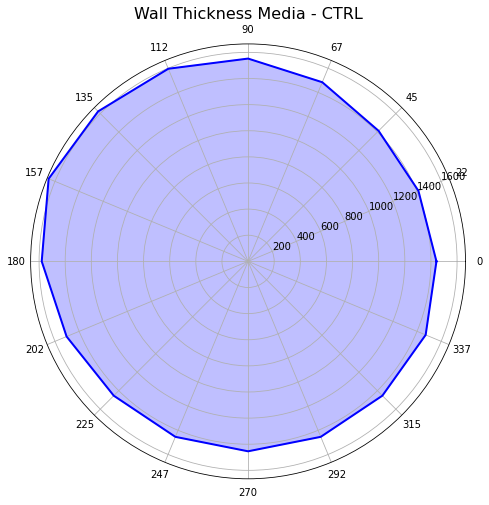

values: [1431.00345556 1582.47902778 1655.81732407 1572.1955     1492.20940741
 1490.45502778 1530.54118704 1572.44944444 1497.3447037  1418.82611111
 1333.06888704 1219.54927778 1110.9653037  1071.48022222 1071.48022222
 1286.11377778]
angles: [0.0, 0.39269908169872414, 0.7853981633974483, 1.1780972450961724, 1.5707963267948966, 1.9634954084936207, 2.356194490192345, 2.748893571891069, 3.141592653589793, 3.5342917352885173, 3.9269908169872414, 4.319689898685965, 4.71238898038469, 5.105088062083414, 5.497787143782138, 5.890486225480862]


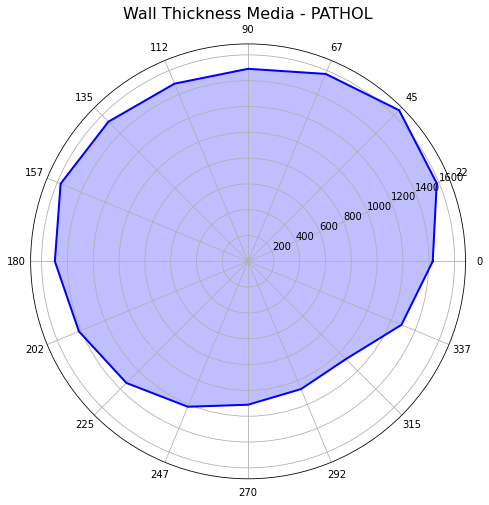

In [256]:
plot_radial_wall_thickness(wall_thickness_avg_interp, group='CTRL')
plot_radial_wall_thickness(wall_thickness_avg_interp, group='PATHOL')

In [257]:
# Salva il DataFrame interpolato in un file Excel   
wall_thickness_avg_interp.to_excel('/home/fra/Pycharm_Projects/whole_heart/data/wall_thickness_avg_interp.xlsx')

In [258]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

def plot_radial_wall_thickness_spicchi(wall_thickness_avg, group='CTRL', title='Radial Plot - Spicchi', filepath='output'):
    """
    Plotta la wall thickness media per un gruppo specifico in un grafico radiale a spicchi (barre),
    colorando ogni fetta in base al proprio valore tra 1 e 2 mm.
    Valori <1 mm saranno colorati come 1 mm (cioè gialli nella plasma_r).
    """
    # Estrai valori e converti in mm
    values = wall_thickness_avg.loc[group].values / 1000
    labels = wall_thickness_avg.columns.tolist()
    n = len(values)

    # Angoli centrali degli spicchi
    theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
    width = 2 * np.pi / n  # larghezza angolare di ogni spicchio

    # Normalizzazione e colormap (da 1 a 2 mm)
    norm = Normalize(vmin=1.0, vmax=2.0)
    cmap = plt.cm.plasma_r
    colors = cmap(norm(values))

    # Setup plot
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 8))
    bars = ax.bar(theta, values, width=width, bottom=0, color=colors, edgecolor='black', linewidth=0.5)

    # Asse radiale
    ax.set_ylim(0, 2.0)

    # Etichette angolari
    ax.set_xticks(theta)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_yticklabels([])

    # Titolo
    ax.set_title(title, fontsize=16)
    
    # sfondo nero
    ax.set_facecolor('black')

    # Colorbar
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array(values)
    cbar = plt.colorbar(sm, ax=ax, pad=0.1)
    cbar.set_label('Wall Thickness (mm)', fontsize=12)
    cbar.set_ticks([1.0, 1.5, 2.0])

    # Salvataggio
    plt.savefig(f"{filepath}_spicchi.png", dpi=300, bbox_inches='tight')
    plt.savefig(f"{filepath}_spicchi.pdf", bbox_inches='tight')
    plt.show()

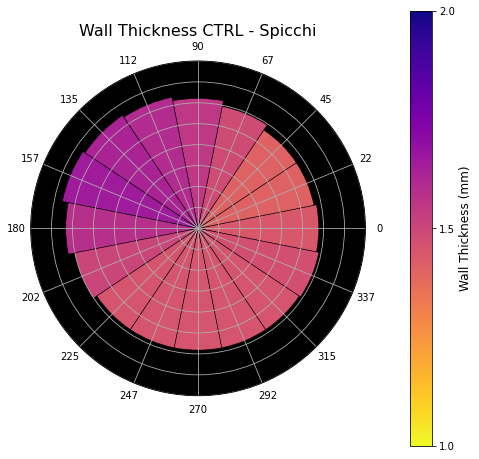

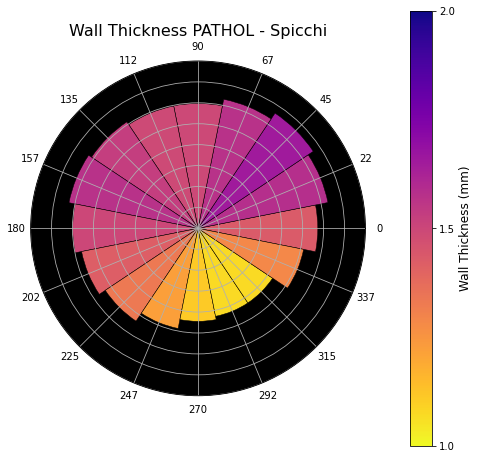

In [259]:
plot_radial_wall_thickness_spicchi(wall_thickness_avg_interp, group='CTRL', title='Wall Thickness CTRL - Spicchi', filepath='/home/fra/Pycharm_Projects/whole_heart/data/wall_thickness_CTRL_spicchi')
plot_radial_wall_thickness_spicchi(wall_thickness_avg_interp, group='PATHOL', title='Wall Thickness PATHOL - Spicchi', filepath='/home/fra/Pycharm_Projects/whole_heart/data/wall_thickness_PATHOL_spicchi')

In [211]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

def plot_wall_thickness_vs_fibrosis(wall_thickness_interp, ctrl_fibrosis, pathol_fibrosis, filepath, ylabel='ylabel', title="title"):
    """
    Plotta la correlazione tra wall thickness interpolata e percentuale di fibrosis per CTRL e PATHOL,
    includendo le linee di regressione, e salva la figura in PDF e PNG.

    Args:
        wall_thickness_interp (pd.DataFrame): DataFrame con i valori interpolati di wall thickness.
        ctrl_fibrosis (pd.Series): Serie con i valori di percentuale di fibrosis per CTRL.
        pathol_fibrosis (pd.Series): Serie con i valori di percentuale di fibrosis per PATHOL.
        filepath (str): Percorso del file per salvare la figura (senza estensione).
        title (str): Titolo del grafico.
    """
    plt.figure(figsize=(10, 6))

    # Estrai i valori
    wall_thickness_ctrl = wall_thickness_interp.loc['CTRL'].values
    wall_thickness_pathol = wall_thickness_interp.loc['PATHOL'].values

    ctrl_fibrosis_values = ctrl_fibrosis.values
    pathol_fibrosis_values = pathol_fibrosis.values

    # Calcola correlazione e regressione lineare
    corr_ctrl = np.corrcoef(wall_thickness_ctrl, ctrl_fibrosis_values)[0, 1]
    corr_pathol = np.corrcoef(wall_thickness_pathol, pathol_fibrosis_values)[0, 1]

    slope_ctrl, intercept_ctrl, *_ = linregress(wall_thickness_ctrl, ctrl_fibrosis_values)
    slope_pathol, intercept_pathol, *_ = linregress(wall_thickness_pathol, pathol_fibrosis_values)

    # Plot dei punti
    plt.scatter(wall_thickness_ctrl, ctrl_fibrosis_values, color='blue', label=f"CTRL (r={corr_ctrl:.2f})")
    plt.scatter(wall_thickness_pathol, pathol_fibrosis_values, color='red', label=f"PATHOL (r={corr_pathol:.2f})")

    # Plot delle rette di regressione
    x_ctrl_line = np.linspace(min(wall_thickness_ctrl), max(wall_thickness_ctrl), 100)
    x_pathol_line = np.linspace(min(wall_thickness_pathol), max(wall_thickness_pathol), 100)

    plt.plot(x_ctrl_line, slope_ctrl * x_ctrl_line + intercept_ctrl, color='blue', linestyle='--')
    plt.plot(x_pathol_line, slope_pathol * x_pathol_line + intercept_pathol, color='red', linestyle='--')

    plt.title(title)
    plt.xlabel('Wall Thickness Interpolata (µm)')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)

    # Salva la figura in PDF e PNG
    plt.savefig(f"{filepath}.pdf", format='pdf')
    plt.savefig(f"{filepath}.png", format='png')

    plt.show()
    


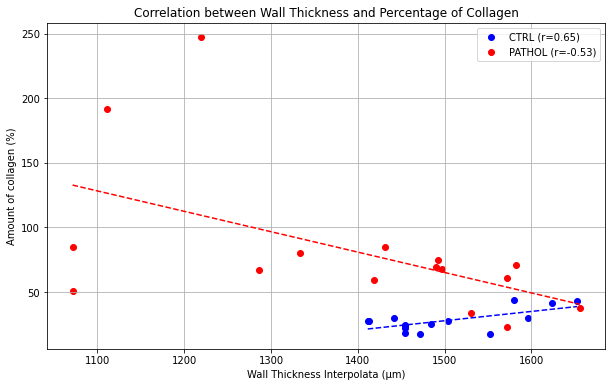

In [212]:
OUT_PATH = '/home/fra/Pycharm_Projects/whole_heart/data/correlation_wallthickness_fibrosis_perc'
plot_wall_thickness_vs_fibrosis(
    wall_thickness_avg_interp,
    CTRL_fibrosis_theta,
    PATHOL_fibrosis_theta,
    title='Correlation between Wall Thickness and Percentage of Collagen',
    ylabel='Amount of collagen (%)',
    filepath=OUT_PATH,
)

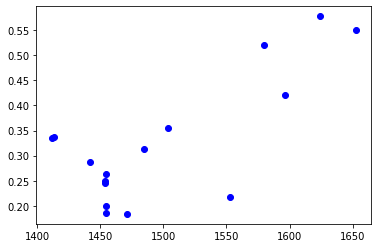

In [156]:
plt.scatter(wall_thickness_avg_interp.loc['CTRL'].values, CTRL_fibrosis_theta.values, color='blue', label='CTRL')

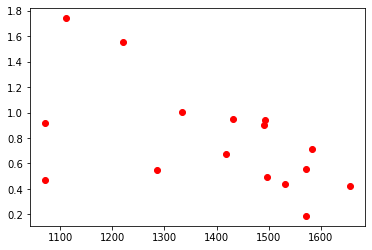

In [157]:
plt.scatter(wall_thickness_avg_interp.loc['PATHOL'].values, PATHOL_fibrosis_theta.values, color='red', label='PATHOL')

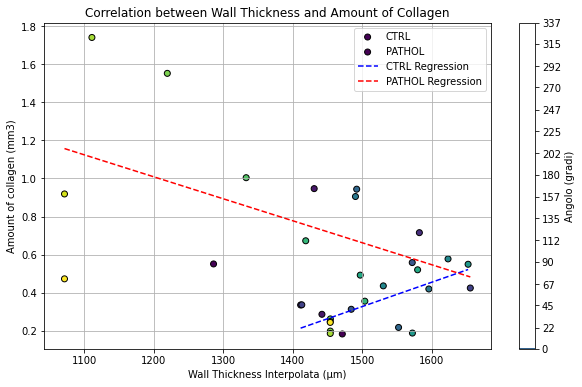

In [217]:
wall_thickness_avg

,0,60,120,180,240,300
Group,,,,,,
CTRL,1471.514889,1391.490444,1577.270667,1652.636556,1454.366556,1454.143667
PATHOL,1286.113778,1681.267444,1463.123556,1572.449444,1367.618333,1071.480222


In [221]:
# estrai la wall_tchikeness media per CTRL e PATHOL

print("Wall thickness avg:", wall_thickness_avg.mean(axis=1))
print("\nWall thickness stddev:", wall_thickness_avg.std(axis=1))
print("\nWall thickness avg coeff of variation:", wall_thickness_avg.std(axis=1) / wall_thickness_avg.mean(axis=1))

Wall thickness avg: Group
CTRL      1500.237130
PATHOL    1407.008796
dtype: float64

Wall thickness stddev: Group
CTRL       95.957570
PATHOL    216.556652
dtype: float64

Wall thickness avg coeff of variation: Group
CTRL      0.063962
PATHOL    0.153913
dtype: float64


In [220]:
# coefficient of variationo
print("Wall thickness avg coeff of variation:", wall_thickness_avg.std(axis=1) / wall_thickness_avg.mean(axis=1))

Wall thickness avg coeff of variation: Group
CTRL      0.063962
PATHOL    0.153913
dtype: float64
